# Compare Rule-Based GE vs AIOps Results

Display-only current-date comparison for streaming GE rule-based detection and AIOps PyTorch autoencoder detection.


In [0]:
from datetime import date
from functools import reduce

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

import matplotlib.pyplot as plt

CATALOG_NAME = "hant-catalog"
SCHEMA_NAME = "hsl"
STORAGE_ACCOUNT = "streanmingdatasta"
LAKEHOUSE_CONTAINER = "lakehouse"
BASE_PATH = f"abfss://{LAKEHOUSE_CONTAINER}@{STORAGE_ACCOUNT}.dfs.core.windows.net/external/hant-catalog"
AIOPS_BASE_PATH = f"{BASE_PATH}/aiops"

dbutils.widgets.text("compare_date", "")
dbutils.widgets.text("top_n", "20")

COMPARE_DATE_VALUE = dbutils.widgets.get("compare_date").strip() or date.today().isoformat()
TOP_N = int(dbutils.widgets.get("top_n"))


def qname(table_name: str) -> str:
    return f"`{CATALOG_NAME}`.{SCHEMA_NAME}.{table_name}"


def table_exists(table_name: str) -> bool:
    try:
        spark.table(qname(table_name)).limit(1).collect()
        return True
    except Exception:
        return False


def path_exists(path: str) -> bool:
    try:
        dbutils.fs.ls(path)
        return True
    except Exception:
        return False


def read_table_or_delta(table_name: str, path: str | None = None) -> DataFrame | None:
    if table_exists(table_name):
        return spark.table(qname(table_name))
    if path and path_exists(path):
        print(f"Reading Delta path because table is not registered: {path}")
        return spark.read.format("delta").load(path)
    return None


def empty_array_string():
    return F.array().cast("array<string>")


def source_type_from_name(col_expr):
    name = F.lower(col_expr)
    return (
        F.when(name.rlike("future|stale|timestamp|producer_ts|event_ts|time|delay|freshness|unix|enqueue|ingest"), F.lit("timeliness"))
         .when(name.rlike("parse|json|mqtt|schema|topic|format|event_type|transport_mode"), F.lit("schema_parse"))
         .when(name.rlike("null|missing|present|required|completeness"), F.lit("completeness"))
         .when(name.rlike("duplicate|unique|mismatch|business_key|partition_offset|consistency"), F.lit("consistency"))
         .when(name.rlike("range|invalid|unexpected|bounds|negative|lat|lon|location|speed|occupancy|hour|domain"), F.lit("validity"))
         .otherwise(F.lit("other"))
    )


def severity_rank(col_expr):
    s = F.lower(col_expr)
    return (
        F.when(s == "critical", F.lit(4))
         .when(s.isin("high", "warning"), F.lit(3))
         .when(s == "medium", F.lit(2))
         .when(s == "low", F.lit(1))
         .otherwise(F.lit(0))
    )


def severity_from_rank(col_expr):
    return (
        F.when(col_expr >= 4, F.lit("critical"))
         .when(col_expr == 3, F.lit("high"))
         .when(col_expr == 2, F.lit("medium"))
         .when(col_expr == 1, F.lit("low"))
         .otherwise(F.lit("normal"))
    )


def severity_band(col_expr):
    s = F.lower(col_expr)
    return (
        F.when(s == "critical", F.lit("CRITICAL"))
         .when(s.isin("high", "medium", "low", "warning"), F.lit("WARNING"))
         .otherwise(F.lit("NORMAL"))
    )


def rule_id_from_feature(feature_col):
    return F.regexp_replace(F.regexp_replace(feature_col, "^rule_", ""), "_flag$", "")


def plot_bar(pdf, x_col, y_col, title, color="#2f5597", horizontal=True, top_n=20):
    if pdf.empty:
        print(f"No data to plot: {title}")
        return
    pdf = pdf.head(top_n).copy()
    plt.figure(figsize=(10, max(4, min(12, len(pdf) * 0.45))))
    if horizontal:
        plt.barh(pdf[x_col].astype(str), pdf[y_col], color=color)
        plt.gca().invert_yaxis()
        plt.xlabel(y_col)
        plt.ylabel("")
    else:
        plt.bar(pdf[x_col].astype(str), pdf[y_col], color=color)
        plt.xticks(rotation=35, ha="right")
        plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


print({"compare_date": COMPARE_DATE_VALUE, "top_n": TOP_N, "display_only": True})


{'compare_date': '2026-04-29', 'top_n': 20, 'display_only': True}


## Normalized GE/AIOps Detections

In [0]:
GE_LAYER_CONFIGS = [
    {
        "layer": "bronze",
        "validated_table": "bronze_vehicle_positions_validated_stream",
        "quarantine_table": "bronze_vehicle_positions_ge_quarantine_stream",
        "rule_metrics_table": "bronze_ge_rule_metrics_hsl_vehicle_positions",
        "rule_ids_col": "failed_rule_ids",
        "severities_col": "failed_severities",
        "descriptions_col": "failed_rule_descriptions",
        "rule_count_col": "failed_rule_count",
        "validation_ts_col": "validation_ts",
        "validation_date_col": "validation_date",
    },
    {
        "layer": "silver",
        "validated_table": "silver_vehicle_positions_validated_stream",
        "quarantine_table": "silver_vehicle_positions_ge_quarantine_stream",
        "rule_metrics_table": "silver_ge_rule_metrics_hsl_vehicle_positions",
        "rule_ids_col": "silver_failed_rule_ids",
        "severities_col": "silver_failed_severities",
        "descriptions_col": "silver_failed_rule_descriptions",
        "rule_count_col": "silver_failed_rule_count",
        "validation_ts_col": "silver_validation_ts",
        "validation_date_col": "silver_validation_date",
    },
    {
        "layer": "gold",
        "validated_table": "gold_vehicle_positions_validated_stream",
        "quarantine_table": "gold_vehicle_positions_ge_quarantine_stream",
        "rule_metrics_table": "gold_ge_rule_metrics_hsl_vehicle_positions",
        "rule_ids_col": "gold_failed_rule_ids",
        "severities_col": "gold_failed_severities",
        "descriptions_col": "gold_failed_rule_descriptions",
        "rule_count_col": "gold_failed_rule_count",
        "validation_ts_col": "gold_validation_ts",
        "validation_date_col": "gold_validation_date",
    },
]

AIOPS_LAYER_CONFIGS = [
    {"layer": "bronze", "decision_table": "report_aiops_bronze_record_decisions", "decision_path": f"{AIOPS_BASE_PATH}/bronze/decisions"},
    {"layer": "silver", "decision_table": "report_aiops_silver_record_decisions", "decision_path": f"{AIOPS_BASE_PATH}/silver/decisions"},
    {"layer": "gold", "decision_table": "report_aiops_gold_record_decisions", "decision_path": f"{AIOPS_BASE_PATH}/gold/decisions"},
]


def severity_from_rule_id(rule_col):
    name = F.lower(rule_col)
    return (
        F.when(name.startswith("critical_"), F.lit("critical"))
         .when(name.startswith("high_"), F.lit("high"))
         .when(name.startswith("medium_"), F.lit("medium"))
         .when(name.startswith("low_"), F.lit("low"))
         .otherwise(F.lit("unknown"))
    )


def load_rule_catalog() -> DataFrame:
    frames = []
    for config in GE_LAYER_CONFIGS:
        table_name = config["rule_metrics_table"]
        if not table_exists(table_name):
            print(f"Missing GE rule metrics table for rule catalog: {qname(table_name)}")
            continue
        df = spark.table(qname(table_name))
        cols = df.columns
        rule_description_col = "rule_description" if "rule_description" in cols else None
        validation_date = F.to_date(F.col("validation_date")) if "validation_date" in cols else F.current_date()
        frames.append(
            df.select(
                F.lit(config["layer"]).alias("layer"),
                F.col("rule_id").cast("string").alias("rule_id"),
                F.col("severity").cast("string").alias("catalog_severity") if "severity" in cols else severity_from_rule_id(F.col("rule_id")).alias("catalog_severity"),
                F.col(rule_description_col).cast("string").alias("catalog_rule_description") if rule_description_col else F.lit(None).cast("string").alias("catalog_rule_description"),
                validation_date.alias("catalog_validation_date"),
            )
        )
    if not frames:
        schema = T.StructType([
            T.StructField("layer", T.StringType(), True),
            T.StructField("rule_id", T.StringType(), True),
            T.StructField("catalog_severity", T.StringType(), True),
            T.StructField("catalog_rule_description", T.StringType(), True),
            T.StructField("catalog_validation_date", T.DateType(), True),
        ])
        return spark.createDataFrame([], schema)
    catalog = reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), frames)
    catalog = catalog.where(F.col("catalog_validation_date") == F.to_date(F.lit(COMPARE_DATE_VALUE)))
    return (
        catalog
        .where(F.col("rule_id").isNotNull())
        .withColumn("rn", F.row_number().over(Window.partitionBy("layer", "rule_id").orderBy(F.col("catalog_rule_description").desc_nulls_last())))
        .where(F.col("rn") == 1)
        .drop("rn", "catalog_validation_date")
    )


rule_catalog = load_rule_catalog()
display(rule_catalog.orderBy("layer", "rule_id"))


def ge_record_id_expr(layer: str, cols: list[str]):
    if layer == "bronze" and {"topic", "partition", "offset"}.issubset(set(cols)):
        return F.concat_ws("|", F.coalesce(F.col("topic"), F.lit("")), F.col("partition").cast("string"), F.col("offset").cast("string"))
    if "business_key" in cols:
        return F.col("business_key").cast("string")
    if {"vehicle_id", "event_ts_unix", "route_id", "direction_id"}.issubset(set(cols)):
        return F.concat_ws("|", F.col("vehicle_id"), F.col("event_ts_unix").cast("string"), F.col("route_id"), F.col("direction_id"))
    return F.sha2(F.to_json(F.struct(*[F.col(c) for c in cols])), 256)


def load_ge_layer(config: dict) -> DataFrame | None:
    frames = []
    for output_type, table_name in [("validated", config["validated_table"]), ("quarantine", config["quarantine_table"])]:
        if not table_exists(table_name):
            print(f"Missing GE table: {qname(table_name)}")
            continue
        df = spark.table(qname(table_name))
        cols = df.columns
        rule_ids = F.col(config["rule_ids_col"]) if config["rule_ids_col"] in cols else empty_array_string()
        severities = F.col(config["severities_col"]) if config["severities_col"] in cols else empty_array_string()
        descriptions = F.col(config["descriptions_col"]) if config["descriptions_col"] in cols else empty_array_string()
        rule_count = F.col(config["rule_count_col"]).cast("long") if config["rule_count_col"] in cols else F.size(rule_ids).cast("long")
        validation_ts = F.col(config["validation_ts_col"]).cast("timestamp") if config["validation_ts_col"] in cols else F.current_timestamp()
        validation_date = F.to_date(F.col(config["validation_date_col"])) if config["validation_date_col"] in cols else F.to_date(validation_ts)
        ingest_date = F.to_date(F.col("ingest_date")) if "ingest_date" in cols else validation_date
        event_ts = F.col("event_ts").cast("timestamp") if "event_ts" in cols else F.lit(None).cast("timestamp")
        business_key = F.col("business_key").cast("string") if "business_key" in cols else F.lit(None).cast("string")
        max_rank = F.array_max(F.transform(severities, lambda x: severity_rank(x)))
        frames.append(
            df.select(
                F.lit(config["layer"]).alias("layer"),
                F.lit("rule_based_ge").alias("detector_type"),
                F.lit(output_type).alias("output_type"),
                ge_record_id_expr(config["layer"], cols).alias("record_id"),
                business_key.alias("business_key"),
                event_ts.alias("event_ts"),
                ingest_date.alias("compare_date"),
                validation_ts.alias("detected_at"),
                rule_ids.alias("rule_ids"),
                severities.alias("rule_severities"),
                descriptions.alias("rule_descriptions"),
                rule_count.alias("rule_hit_count"),
                F.coalesce(max_rank, F.lit(0)).alias("severity_rank"),
                F.lit(None).cast("double").alias("anomaly_score"),
                F.lit(None).cast("string").alias("primary_source_type"),
                F.lit(None).cast("string").alias("source_type_coverage_json"),
                F.lit(None).cast("string").alias("top_contributing_features_json"),
            )
        )
    if not frames:
        return None
    return reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), frames)


def load_aiops_layer(config: dict) -> DataFrame | None:
    table_name = config["decision_table"]
    df = read_table_or_delta(table_name, config.get("decision_path"))
    if df is None:
        print(f"Missing AIOps decision table/path: {qname(table_name)} OR {config.get('decision_path')}")
        return None
    cols = df.columns
    scored_at = F.col("scored_at").cast("timestamp") if "scored_at" in cols else F.current_timestamp()
    scored_date = F.to_date(F.col("scored_date")) if "scored_date" in cols else F.to_date(scored_at)
    feature_date = F.to_date(F.col("feature_date")) if "feature_date" in cols else scored_date
    ingest_date = F.to_date(F.col("ingest_date")) if "ingest_date" in cols else feature_date
    business_key = F.col("business_key").cast("string") if "business_key" in cols else F.lit(None).cast("string")
    decision_action = F.coalesce(F.col("decision_action"), F.lit("PASS"))
    aiops_severity = F.coalesce(F.col("aiops_severity"), F.lit("NORMAL"))
    return df.select(
        F.lit(config["layer"]).alias("layer"),
        F.lit("aiops_autoencoder").alias("detector_type"),
        decision_action.alias("output_type"),
        F.col("record_id").cast("string").alias("record_id"),
        business_key.alias("business_key"),
        F.col("event_ts").cast("timestamp").alias("event_ts") if "event_ts" in cols else F.lit(None).cast("timestamp").alias("event_ts"),
        ingest_date.alias("compare_date"),
        scored_at.alias("detected_at"),
        empty_array_string().alias("rule_ids"),
        empty_array_string().alias("rule_severities"),
        empty_array_string().alias("rule_descriptions"),
        F.lit(0).cast("long").alias("rule_hit_count"),
        severity_rank(aiops_severity).alias("severity_rank"),
        F.col("reconstruction_error").cast("double").alias("anomaly_score") if "reconstruction_error" in cols else F.lit(None).cast("double").alias("anomaly_score"),
        F.col("primary_source_type").cast("string").alias("primary_source_type") if "primary_source_type" in cols else F.lit(None).cast("string").alias("primary_source_type"),
        F.col("source_type_coverage_json").cast("string").alias("source_type_coverage_json") if "source_type_coverage_json" in cols else F.lit(None).cast("string").alias("source_type_coverage_json"),
        F.col("top_contributing_features_json").cast("string").alias("top_contributing_features_json") if "top_contributing_features_json" in cols else F.lit(None).cast("string").alias("top_contributing_features_json"),
    )


rule_frames = [df for df in [load_ge_layer(c) for c in GE_LAYER_CONFIGS] if df is not None]
aiops_frames = [df for df in [load_aiops_layer(c) for c in AIOPS_LAYER_CONFIGS] if df is not None]

if not rule_frames:
    raise ValueError("No GE validated/quarantine tables found.")
if not aiops_frames:
    raise ValueError("No AIOps decision tables found.")

rule = reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), rule_frames)
aiops = reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), aiops_frames)

rule = rule.where(F.col("compare_date") == F.to_date(F.lit(COMPARE_DATE_VALUE))).withColumn("comparison_id", F.coalesce(F.col("business_key"), F.col("record_id")))
aiops = aiops.where(F.col("compare_date") == F.to_date(F.lit(COMPARE_DATE_VALUE))).withColumn("comparison_id", F.coalesce(F.col("business_key"), F.col("record_id")))

rule_detected = (
    rule.where(F.col("rule_hit_count") > 0)
    .withColumn("severity", severity_from_rank(F.col("severity_rank")))
    .withColumn("severity_band", severity_band(F.col("severity")))
)
aiops_detected = (
    aiops.where(F.col("output_type").isin("WARN", "QUARANTINE"))
    .withColumn("severity", F.when(F.col("output_type") == "QUARANTINE", F.lit("critical")).when(F.col("output_type") == "WARN", F.lit("warning")).otherwise(F.lit("normal")))
    .withColumn("severity_band", severity_band(F.col("severity")))
)

all_detections = rule_detected.unionByName(aiops_detected, allowMissingColumns=True)

normalized_detection_summary = all_detections.groupBy("detector_type", "layer", "severity", "severity_band").count().orderBy("layer", "detector_type", "severity")
display(normalized_detection_summary)


## AIOps records by severity and by rule

layer,severity,severity_band,source_type,aiops_rule_id,record_count,avg_anomaly_score,total_contribution
silver,warning,WARNING,validity,heading_clipped,9906,0.10528163240488048,2363.870157097813
silver,warning,WARNING,validity,latitude_clipped,9906,0.10528163240488048,1873.6663176364434
silver,warning,WARNING,validity,speed_clipped,9906,0.10528163240488048,771.2984440052571
silver,warning,WARNING,timeliness,event_to_silver_delay_clipped,9906,0.10528163240488048,471.5360338251569
silver,warning,WARNING,validity,occupancy_clipped,9906,0.10528163240488048,409.921409088822
silver,warning,WARNING,validity,longitude_clipped,9906,0.10528163240488048,367.2267247911874
silver,critical,CRITICAL,validity,latitude_clipped,2040,16077.566801253035,1.1029689105022049E8
silver,critical,CRITICAL,validity,speed_clipped,2040,16077.566801253035,4.98632649285841E7
silver,critical,CRITICAL,validity,heading_clipped,2040,16077.566801253035,2.4956249641821384E7
silver,critical,CRITICAL,validity,longitude_clipped,2040,16077.566801253035,1.0409416126988675E7


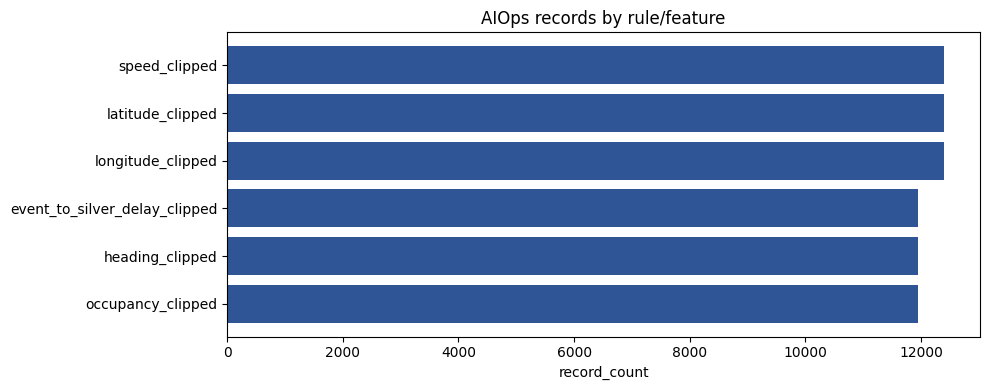

In [0]:
feature_schema = T.ArrayType(T.StructType([
    T.StructField("feature", T.StringType(), True),
    T.StructField("contribution", T.DoubleType(), True),
    T.StructField("source_type", T.StringType(), True),
]))

aiops_features = (
    aiops_detected
    .withColumn("top_feature", F.explode_outer(F.from_json("top_contributing_features_json", feature_schema)))
    .where(F.col("top_feature.feature").isNotNull())
    .withColumn("feature", F.col("top_feature.feature"))
    .withColumn("source_type", F.coalesce(F.col("top_feature.source_type"), source_type_from_name(F.col("feature"))))
    .withColumn("aiops_rule_id", F.when(F.col("feature").startswith("rule_") & F.col("feature").endswith("_flag"), rule_id_from_feature(F.col("feature"))).otherwise(F.col("feature")))
)

aiops_by_severity_rule = (
    aiops_features
    .groupBy("layer", "severity", "severity_band", "source_type", "aiops_rule_id")
    .agg(
        F.countDistinct("comparison_id").alias("record_count"),
        F.avg("anomaly_score").alias("avg_anomaly_score"),
        F.sum("top_feature.contribution").alias("total_contribution"),
    )
    .orderBy(F.desc("record_count"), F.desc("total_contribution"))
)

display(aiops_by_severity_rule)
plot_bar(aiops_by_severity_rule.select("aiops_rule_id", "record_count").groupBy("aiops_rule_id").agg(F.sum("record_count").alias("record_count")).orderBy(F.desc("record_count")).toPandas(), "aiops_rule_id", "record_count", "AIOps records by rule/feature", "#2f5597", top_n=TOP_N)


## Rule records by severity and by rule

layer,severity,severity_band,source_type,rule_id,rule_description,rule_hit_count,record_count
bronze,medium,WARNING,timeliness,medium_producer_ts_bad_format,Producer ingest timestamp should be ISO-8601 UTC ending with Z.,142385,142385
silver,medium,WARNING,timeliness,medium_event_stale_gt_5m,Event timestamp is more than 5 minutes older than Silver ingest time.,128280,128280
silver,low,WARNING,schema_parse,low_topic_operator_mismatch,Topic operator ID and payload operator ID should usually agree after normalization.,32977,32977
silver,high,WARNING,validity,high_longitude_out_of_bounds,Longitude must fall within HSL operating bounds.,1204,1204
silver,high,WARNING,validity,high_latitude_out_of_bounds,Latitude must fall within HSL operating bounds.,1204,1204


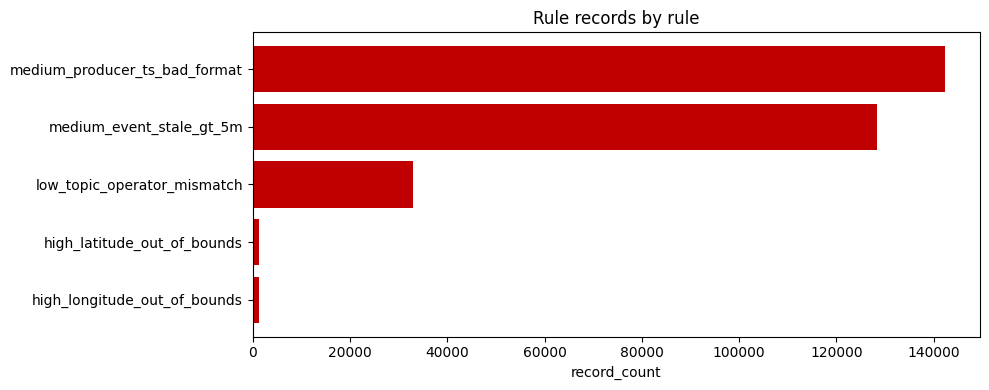

In [0]:
rule_exploded = (
    rule_detected
    .select("layer", "comparison_id", F.posexplode_outer("rule_ids").alias("rule_pos", "rule_id"))
    .where(F.col("rule_id").isNotNull())
    .join(rule_catalog, on=["layer", "rule_id"], how="left")
    .withColumn("severity", F.coalesce(F.col("catalog_severity"), severity_from_rule_id(F.col("rule_id"))))
    .withColumn("severity_band", severity_band(F.col("severity")))
    .withColumn("rule_description", F.col("catalog_rule_description"))
    .withColumn("source_type", source_type_from_name(F.col("rule_id")))
)

rule_by_severity_rule = (
    rule_exploded
    .groupBy("layer", "severity", "severity_band", "source_type", "rule_id", "rule_description")
    .agg(
        F.count("rule_id").alias("rule_hit_count"),
        F.countDistinct("comparison_id").alias("record_count"),
    )
    .orderBy(F.desc("record_count"), F.desc("rule_hit_count"))
)

display(rule_by_severity_rule)
plot_bar(rule_by_severity_rule.select("rule_id", "record_count").groupBy("rule_id").agg(F.sum("record_count").alias("record_count")).orderBy(F.desc("record_count")).toPandas(), "rule_id", "record_count", "Rule records by rule", "#c00000", top_n=TOP_N)


## Detection overlap matrix

layer,rule_only,aiops_only,both,total_detected_records
bronze,142385,0,0,142385
gold,0,456,0,456
silver,116334,0,11946,128280


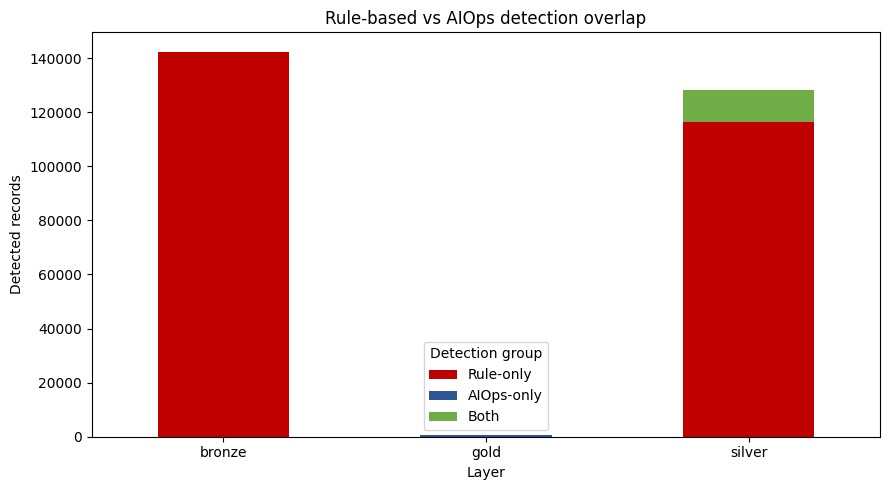

In [0]:
key_cols = ["layer", "comparison_id"]

rule_keys = rule_detected.select(*key_cols).dropDuplicates().withColumn("rule_detected", F.lit(1))
aiops_keys = aiops_detected.select(*key_cols).dropDuplicates().withColumn("aiops_detected", F.lit(1))

overlap = (
    rule_keys.join(aiops_keys, key_cols, "full_outer")
    .fillna({"rule_detected": 0, "aiops_detected": 0})
    .withColumn(
        "overlap_type",
        F.when((F.col("rule_detected") == 1) & (F.col("aiops_detected") == 1), "both")
         .when(F.col("rule_detected") == 1, "rule_only")
         .otherwise("aiops_only")
    )
)

overlap_matrix = (
    overlap
    .groupBy("layer")
    .pivot("overlap_type", ["rule_only", "aiops_only", "both"])
    .count()
    .fillna(0)
    .withColumn("total_detected_records", F.col("rule_only") + F.col("aiops_only") + F.col("both"))
    .orderBy("layer")
)

display(overlap_matrix)

overlap_pdf = overlap_matrix.toPandas()
if overlap_pdf.empty:
    print("No overlap data to plot.")
else:
    ax = overlap_pdf.set_index("layer")[["rule_only", "aiops_only", "both"]].plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5),
        color=["#c00000", "#2f5597", "#70ad47"],
    )
    ax.set_xlabel("Layer")
    ax.set_ylabel("Detected records")
    ax.set_title("Rule-based vs AIOps detection overlap")
    ax.legend(["Rule-only", "AIOps-only", "Both"], title="Detection group")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## AIOps-only records that passed rules

In [0]:
aiops_only_records = overlap.where(F.col("overlap_type") == "aiops_only").select(*key_cols)
aiops_only_detail = aiops_only_records.join(aiops_detected, key_cols, "inner")

display(
    aiops_only_detail
    .select("layer", "comparison_id", "record_id", "business_key", "event_ts", "severity", "output_type", "anomaly_score", "primary_source_type", "top_contributing_features_json")
    .orderBy("layer", F.desc("anomaly_score"))
)


layer,comparison_id,record_id,business_key,event_ts,severity,output_type,anomaly_score,primary_source_type,top_contributing_features_json
gold,90_6085|1777435201|3001Z|2,90_6085|1777435201|3001Z|2,90_6085|1777435201|3001Z|2,2026-04-29T04:00:01.251Z,critical,QUARANTINE,0.11288730055093765,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.24097840487957, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05464457347989082, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.04303891584277153, ""source_type"": ""validity""}]"
gold,90_6085|1777435200|3001Z|2,90_6085|1777435200|3001Z|2,90_6085|1777435200|3001Z|2,2026-04-29T04:00:00.251Z,critical,QUARANTINE,0.11276188492774963,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.24093928933143616, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05463799834251404, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.042708367109298706, ""source_type"": ""validity""}]"
gold,90_6098|1777435201|3001Z|2,90_6098|1777435201|3001Z|2,90_6098|1777435201|3001Z|2,2026-04-29T04:00:01.251Z,critical,QUARANTINE,0.11274979263544083,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.240579292178154, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05459330976009369, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.043076787143945694, ""source_type"": ""validity""}]"
gold,90_6051|1777435201|3001Z|2,90_6051|1777435201|3001Z|2,90_6051|1777435201|3001Z|2,2026-04-29T04:00:01.254Z,critical,QUARANTINE,0.11260282248258591,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.2401723861694336, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05454006791114807, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.04309600219130516, ""source_type"": ""validity""}]"
gold,90_6098|1777435200|3001Z|2,90_6098|1777435200|3001Z|2,90_6098|1777435200|3001Z|2,2026-04-29T04:00:00.251Z,critical,QUARANTINE,0.1126025840640068,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.2405114322900772, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.054584063589572906, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.0427122488617897, ""source_type"": ""validity""}]"
gold,90_6085|1777435199|3001Z|2,90_6085|1777435199|3001Z|2,90_6085|1777435199|3001Z|2,2026-04-29T03:59:59.25Z,critical,QUARANTINE,0.11258883029222488,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.24083393812179565, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05462272837758064, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.04230980947613716, ""source_type"": ""validity""}]"
gold,90_6098|1777435199|3001Z|2,90_6098|1777435199|3001Z|2,90_6098|1777435199|3001Z|2,2026-04-29T03:59:59.251Z,critical,QUARANTINE,0.11246582120656967,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.24045579135417938, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.0545755960047245, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.042366065084934235, ""source_type"": ""validity""}]"
gold,90_6051|1777435200|3001Z|2,90_6051|1777435200|3001Z|2,90_6051|1777435200|3001Z|2,2026-04-29T04:00:00.254Z,critical,QUARANTINE,0.11244511604309082,validity,"[{""feature"": ""longitude_clipped"", ""contribution"": 0.24009083211421967, ""source_type"": ""validity""}, {""feature"": ""speed_clipped"", ""contribution"": 0.05452948808670044, ""source_type"": ""validity""}, {""feature"": ""latitude_clipped"", ""contribution"": 0.042715027928352356, ""source_type"": ""validity""}]"
gold,90_6085

## Rule-based only that passed AIOps

In [0]:
rule_only_records = overlap.where(F.col("overlap_type") == "rule_only").select(*key_cols)
rule_only_detail = rule_only_records.join(rule_detected, key_cols, "inner")

display(
    rule_only_detail
    .select("layer", "comparison_id", "record_id", "business_key", "event_ts", "severity", "rule_hit_count", "rule_ids", "rule_severities", "rule_descriptions")
    .orderBy("layer", F.desc("rule_hit_count"))
)


layer,comparison_id,record_id,business_key,event_ts,severity,rule_hit_count,rule_ids,rule_severities,rule_descriptions
bronze,vehicle-position-events|1|3662780,vehicle-position-events|1|3662780,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3615503,vehicle-position-events|0|3615503,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3636459,vehicle-position-events|0|3636459,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3607019,vehicle-position-events|0|3607019,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3653052,vehicle-position-events|0|3653052,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|1|3643887,vehicle-position-events|1|3643887,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3652403,vehicle-position-events|0|3652403,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|1|3616369,vehicle-position-events|1|3616369,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|1|3601418,vehicle-position-events|1|3601418,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)
bronze,vehicle-position-events|0|3606258,vehicle-position-events|0|3606258,null,null,medium,1,List(medium_producer_ts_bad_format),List(medium),List(Producer ingest timestamp should be ISO-8601 UTC ending with Z.)


## AIOps-only records by severity

layer,severity,severity_band,record_count,avg_anomaly_score
gold,warning,WARNING,342,0.04420213906737099
gold,critical,CRITICAL,114,0.10798192181085285


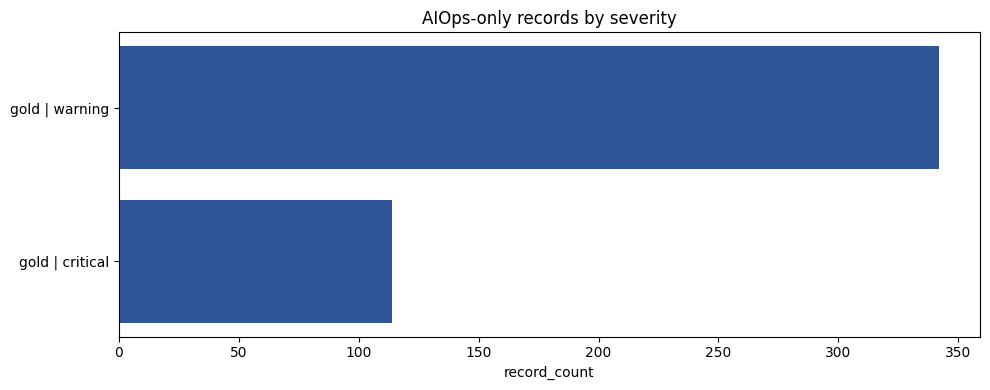

In [0]:
aiops_only_by_severity = (
    aiops_only_detail
    .groupBy("layer", "severity", "severity_band")
    .agg(F.countDistinct("comparison_id").alias("record_count"), F.avg("anomaly_score").alias("avg_anomaly_score"))
    .orderBy(F.desc("record_count"))
)

display(aiops_only_by_severity)
plot_bar(aiops_only_by_severity.withColumn("label", F.concat_ws(" | ", "layer", "severity")).select("label", "record_count").orderBy(F.desc("record_count")).toPandas(), "label", "record_count", "AIOps-only records by severity", "#2f5597", top_n=TOP_N)


## Rule-based records by severity

layer,severity,severity_band,record_count,rule_hit_count
bronze,medium,WARNING,142385,142385
silver,medium,WARNING,116329,144545
silver,high,WARNING,5,15


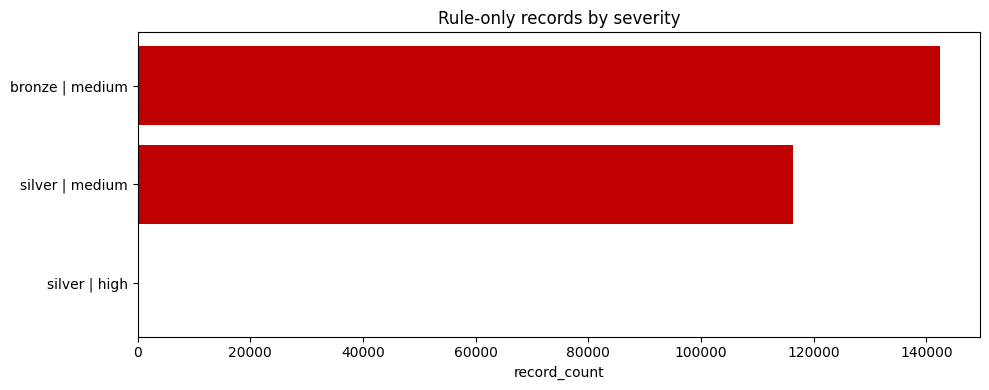

In [0]:
rule_only_by_severity = (
    rule_only_detail
    .groupBy("layer", "severity", "severity_band")
    .agg(F.countDistinct("comparison_id").alias("record_count"), F.sum("rule_hit_count").alias("rule_hit_count"))
    .orderBy(F.desc("record_count"))
)

display(rule_only_by_severity)
plot_bar(rule_only_by_severity.withColumn("label", F.concat_ws(" | ", "layer", "severity")).select("label", "record_count").orderBy(F.desc("record_count")).toPandas(), "label", "record_count", "Rule-only records by severity", "#c00000", top_n=TOP_N)


## AIOps-only records by error

layer,error_type,feature,record_count,total_contribution,avg_anomaly_score
gold,validity,longitude_clipped,456,57.40467332676053,0.06014708475324146
gold,validity,latitude_clipped,456,15.941686198687432,0.06014708475324146
gold,validity,speed_clipped,456,8.934852314429122,0.06014708475324146


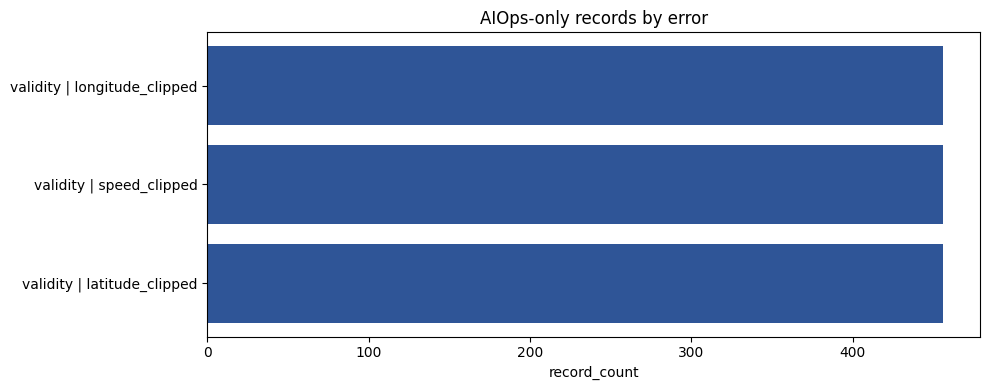

In [0]:
aiops_only_by_error = (
    aiops_only_detail
    .withColumn("top_feature", F.explode_outer(F.from_json("top_contributing_features_json", feature_schema)))
    .where(F.col("top_feature.feature").isNotNull())
    .withColumn("error_type", F.coalesce(F.col("top_feature.source_type"), source_type_from_name(F.col("top_feature.feature"))))
    .groupBy("layer", "error_type", F.col("top_feature.feature").alias("feature"))
    .agg(
        F.countDistinct("comparison_id").alias("record_count"),
        F.sum("top_feature.contribution").alias("total_contribution"),
        F.avg("anomaly_score").alias("avg_anomaly_score"),
    )
    .orderBy(F.desc("record_count"), F.desc("total_contribution"))
)

display(aiops_only_by_error)
plot_bar(aiops_only_by_error.withColumn("label", F.concat_ws(" | ", "error_type", "feature")).select("label", "record_count").orderBy(F.desc("record_count")).toPandas(), "label", "record_count", "AIOps-only records by error", "#2f5597", top_n=TOP_N)


## Rule-only records by error

layer,error_type,severity,rule_id,rule_description,rule_hit_count,record_count
bronze,timeliness,medium,medium_producer_ts_bad_format,Producer ingest timestamp should be ISO-8601 UTC ending with Z.,142385,142385
silver,timeliness,medium,medium_event_stale_gt_5m,Event timestamp is more than 5 minutes older than Silver ingest time.,116334,116334
silver,schema_parse,low,low_topic_operator_mismatch,Topic operator ID and payload operator ID should usually agree after normalization.,28216,28216
silver,validity,high,high_longitude_out_of_bounds,Longitude must fall within HSL operating bounds.,5,5
silver,validity,high,high_latitude_out_of_bounds,Latitude must fall within HSL operating bounds.,5,5


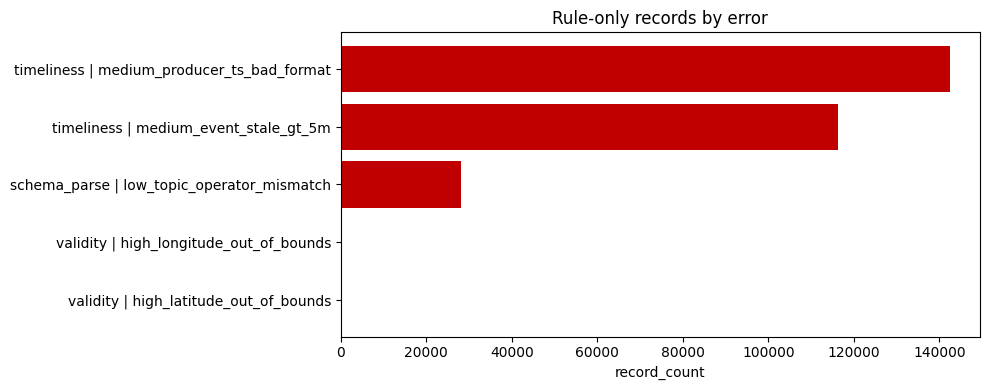

In [0]:
rule_only_by_error = (
    rule_only_detail
    .select("layer", "comparison_id", F.posexplode_outer("rule_ids").alias("rule_pos", "rule_id"))
    .where(F.col("rule_id").isNotNull())
    .join(rule_catalog, on=["layer", "rule_id"], how="left")
    .withColumn("severity", F.coalesce(F.col("catalog_severity"), severity_from_rule_id(F.col("rule_id"))))
    .withColumn("rule_description", F.col("catalog_rule_description"))
    .withColumn("error_type", source_type_from_name(F.col("rule_id")))
    .groupBy("layer", "error_type", "severity", "rule_id", "rule_description")
    .agg(F.count("rule_id").alias("rule_hit_count"), F.countDistinct("comparison_id").alias("record_count"))
    .orderBy(F.desc("record_count"), F.desc("rule_hit_count"))
)

display(rule_only_by_error)
plot_bar(rule_only_by_error.withColumn("label", F.concat_ws(" | ", "error_type", "rule_id")).select("label", "record_count").orderBy(F.desc("record_count")).toPandas(), "label", "record_count", "Rule-only records by error", "#c00000", top_n=TOP_N)


## Both-detected severity and error agreement

This section checks whether Rule-based and AIOps assign the same severity for records detected by both approaches. It also summarizes which predefined rule error types appear in the BOTH group.


layer,rule_severity,aiops_severity,record_count,avg_anomaly_score
silver,medium,warning,9905,0.10528081633914065
silver,high,critical,1198,27240.720703125
silver,medium,critical,842,194.59961070361018
silver,high,warning,1,0.11336476355791092


layer,error_type,rule_severity,rule_id,rule_hit_count,record_count
silver,timeliness,medium,medium_event_stale_gt_5m,11946,11946
silver,schema_parse,low,low_topic_operator_mismatch,4761,4761
silver,validity,high,high_latitude_out_of_bounds,1199,1199
silver,validity,high,high_longitude_out_of_bounds,1199,1199


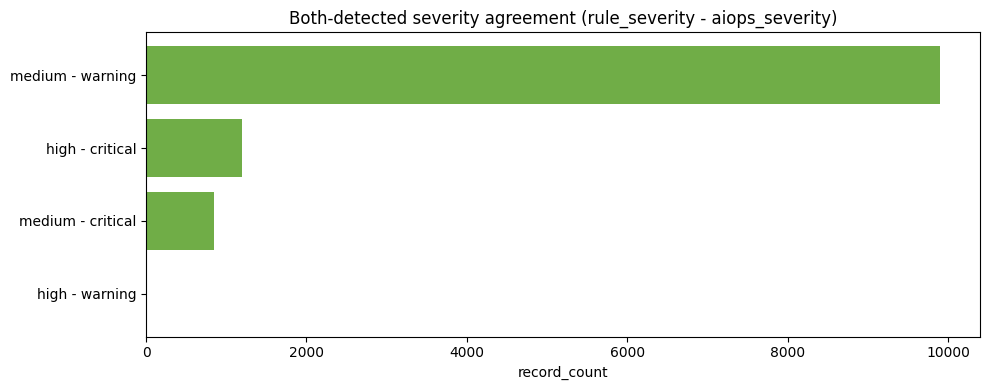

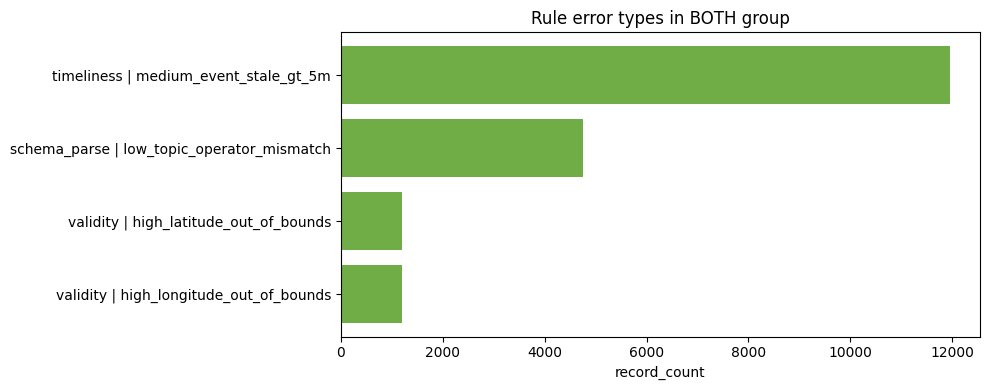

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6365992909425939>, line 21
      3 both_rule = both_records.join(rule_detected, key_cols, "inner").select(
      4     *key_cols,
      5     F.col("severity").alias("rule_severity"),
   (...)
      8     "rule_severities",
      9 )
     10 both_aiops = both_records.join(aiops_detected, key_cols, "inner").select(
     11     *key_cols,
     12     F.col("severity").alias("aiops_severity"),
   (...)
     15     F.col("anomaly_score"),
     16 )
     18 both_agreement = (
     19     both_rule.join(both_aiops, key_cols, "inner")
     20     .groupBy("layer", "rule_severity", "aiops_severity", "severity_agreement")
---> 21     .agg(F.countDistinct("comparison_id").alias("record_count"), F.avg("anomaly_score").alias("avg_anomaly_score"))
     22     .orderBy(F.desc("record_count"))
     23 )
     25 both_rule_errors = (
     

In [0]:
both_records = overlap.where(F.col("overlap_type") == "both").select(*key_cols)

both_rule = both_records.join(rule_detected, key_cols, "inner").select(
    *key_cols,
    F.col("severity").alias("rule_severity"),
    F.col("severity_band").alias("rule_severity_band"),
    "rule_ids",
    "rule_severities",
)
both_aiops = both_records.join(aiops_detected, key_cols, "inner").select(
    *key_cols,
    F.col("severity").alias("aiops_severity"),
    F.col("severity_band").alias("aiops_severity_band"),
    F.col("primary_source_type").alias("aiops_primary_source_type"),
    F.col("anomaly_score"),
)

both_agreement = (
    both_rule.join(both_aiops, key_cols, "inner")
    .groupBy("layer", "rule_severity", "aiops_severity")
    .agg(
        F.countDistinct("comparison_id").alias("record_count"),
        F.avg("anomaly_score").alias("avg_anomaly_score"),
    )
    .orderBy(F.desc("record_count"))
)

both_rule_errors = (
    both_rule
    .select("layer", "comparison_id", F.posexplode_outer("rule_ids").alias("rule_pos", "rule_id"))
    .where(F.col("rule_id").isNotNull())
    .join(rule_catalog, on=["layer", "rule_id"], how="left")
    .withColumn("rule_severity", F.coalesce(F.col("catalog_severity"), severity_from_rule_id(F.col("rule_id"))))
    .withColumn("error_type", source_type_from_name(F.col("rule_id")))
    .groupBy("layer", "error_type", "rule_severity", "rule_id")
    .agg(F.count("rule_id").alias("rule_hit_count"), F.countDistinct("comparison_id").alias("record_count"))
    .orderBy(F.desc("record_count"), F.desc("rule_hit_count"))
)

display(both_agreement)
display(both_rule_errors)

plot_bar(
    both_agreement
    .withColumn("label", F.concat_ws(" - ", "rule_severity", "aiops_severity"))
    .select("label", "record_count")
    .orderBy(F.desc("record_count"))
    .toPandas(),
    "label",
    "record_count",
    "Both-detected severity agreement (rule_severity - aiops_severity)",
    "#70ad47",
    top_n=TOP_N,
)

plot_bar(both_rule_errors.withColumn("label", F.concat_ws(" | ", "error_type", "rule_id")).select("label", "record_count").orderBy(F.desc("record_count")).toPandas(), "label", "record_count", "Rule error types in BOTH group", "#70ad47", top_n=TOP_N)


In [0]:
top_feature_schema = T.ArrayType(
    T.StructType([
        T.StructField("feature", T.StringType(), True),
        T.StructField("contribution", T.DoubleType(), True),
        T.StructField("source_type", T.StringType(), True),
    ])
)

both_rule_record_errors = (
    both_rule
    .select(*key_cols, F.explode_outer("rule_ids").alias("rule_id"))
    .where(F.col("rule_id").isNotNull())
    .withColumn("rule_error", F.col("rule_id"))
    .select(*key_cols, "rule_error")
    .distinct()
)

both_aiops_record_errors = (
    both_aiops
    .join(
        aiops_detected.select(*key_cols, "top_contributing_features_json"),
        key_cols,
        "left",
    )
    .withColumn("top_features", F.from_json("top_contributing_features_json", top_feature_schema))
    .withColumn("top_feature", F.explode_outer("top_features"))
    .withColumn(
        "aiops_error",
        F.coalesce(
            F.col("top_feature.feature"),
            F.col("aiops_primary_source_type"),
            F.lit("unknown"),
        ),
    )
    .select(*key_cols, "aiops_error")
    .where(F.col("aiops_error").isNotNull())
    .distinct()
)

both_error_agreement = (
    both_rule_record_errors
    .join(both_aiops_record_errors, key_cols, "inner")
    .groupBy("layer", "rule_error", "aiops_error")
    .agg(F.countDistinct("comparison_id").alias("record_count"))
    .orderBy(F.desc("record_count"), "layer", "rule_error", "aiops_error")
)

display(both_error_agreement)

plot_bar(
    both_error_agreement
    .withColumn("label", F.concat_ws(" - ", "rule_error", "aiops_error"))
    .select("label", "record_count")
    .orderBy(F.desc("record_count"))
    .toPandas(),
    "label",
    "record_count",
    "Both-detected error agreement (Rule error - AIOPS error)",
    "#70ad47",
    top_n=TOP_N,
)


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-7443662384957600>, line 1
----> 1 top_feature_schema = T.ArrayType(
      2     T.StructType([
      3         T.StructField("feature", T.StringType(), True),
      4         T.StructField("contribution", T.DoubleType(), True),
      5         T.StructField("source_type", T.StringType(), True),
      6     ])
      7 )
      9 both_rule_record_errors = (
     10     both_rule
     11     .select(*key_cols, F.explode_outer("rule_ids").alias("rule_id"))
   (...)
     15     .distinct()
     16 )
     18 both_aiops_record_errors = (
     19     both_aiops
     20     .join(
   (...)
     37     .distinct()
     38 )

NameError: name 'T' is not defined

## Runtime comparison

In [0]:
GE_GATE_TABLES = {
    "bronze": "bronze_gate_results_hsl_vehicle_positions",
    "silver": "silver_gate_results_hsl_vehicle_positions",
    "gold": "gold_gate_results_hsl_vehicle_positions",
}
AIOPS_RUNTIME_TABLE = "report_aiops_runtime_metrics"
AIOPS_RUNTIME_PATH = f"{AIOPS_BASE_PATH}/runtime/report_aiops_runtime_metrics"


def load_ge_gate(layer: str, table_name: str) -> DataFrame | None:
    if not table_exists(table_name):
        return None
    df = spark.table(qname(table_name))
    cols = df.columns
    run_ts = F.col("run_ts_utc").cast("timestamp") if "run_ts_utc" in cols else F.current_timestamp()
    validation_date = F.to_date(F.col("validation_date")) if "validation_date" in cols else F.to_date(run_ts)
    return df.select(
        F.lit(layer).alias("layer"),
        F.lit("GE").alias("approach"),
        validation_date.alias("compare_date"),
        F.col("input_row_count").cast("long").alias("input_record_count") if "input_row_count" in cols else F.lit(None).cast("long").alias("input_record_count"),
        F.col("validated_row_count").cast("long").alias("output_record_count") if "validated_row_count" in cols else F.lit(None).cast("long").alias("output_record_count"),
        F.col("quarantined_row_count").cast("long").alias("flagged_record_count") if "quarantined_row_count" in cols else F.lit(None).cast("long").alias("flagged_record_count"),
        F.lit(None).cast("double").alias("runtime_ms"),
        F.col("gate_status").cast("string").alias("status") if "gate_status" in cols else F.lit(None).cast("string").alias("status"),
    )

runtime_frames = [df for df in [load_ge_gate(layer, table) for layer, table in GE_GATE_TABLES.items()] if df is not None]

runtime_df = read_table_or_delta(AIOPS_RUNTIME_TABLE, AIOPS_RUNTIME_PATH)
if runtime_df is not None:
    cols = runtime_df.columns
    runtime_frames.append(runtime_df.select(
        F.col("layer").cast("string").alias("layer"),
        F.lit("AIOps").alias("approach"),
        F.to_date(F.col("runtime_date")).alias("compare_date") if "runtime_date" in cols else F.to_date(F.col("runtime_ts")).alias("compare_date"),
        F.col("input_record_count").cast("long").alias("input_record_count") if "input_record_count" in cols else F.lit(None).cast("long").alias("input_record_count"),
        F.col("scored_record_count").cast("long").alias("output_record_count") if "scored_record_count" in cols else F.lit(None).cast("long").alias("output_record_count"),
        F.lit(None).cast("long").alias("flagged_record_count"),
        F.col("runtime_ms").cast("double").alias("runtime_ms") if "runtime_ms" in cols else F.lit(None).cast("double").alias("runtime_ms"),
        F.lit(None).cast("string").alias("status"),
    ))

if runtime_frames:
    runtime_comparison = (
        reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), runtime_frames)
        .where(F.col("compare_date") == F.to_date(F.lit(COMPARE_DATE_VALUE)))
        .groupBy("layer", "approach", "compare_date")
        .agg(
            F.count("*").alias("microbatch_count"),
            F.sum("input_record_count").alias("input_record_count"),
            F.sum("output_record_count").alias("output_record_count"),
            F.sum("flagged_record_count").alias("flagged_record_count"),
            F.sum("runtime_ms").alias("total_runtime_ms"),
            F.avg("runtime_ms").alias("avg_runtime_ms"),
            F.sum(F.when(F.col("status") == "BLOCK", 1).otherwise(0)).alias("block_batches"),
            F.sum(F.when(F.col("status") == "WARN", 1).otherwise(0)).alias("warn_batches"),
            F.sum(F.when(F.col("status") == "PASS", 1).otherwise(0)).alias("pass_batches"),
        )
        .withColumn("records_per_second", F.when(F.col("total_runtime_ms") > 0, F.round(F.col("output_record_count") / (F.col("total_runtime_ms") / 1000.0), 2)))
        .orderBy("layer", "approach")
    )
    display(runtime_comparison)
else:
    print("No runtime/gate tables found.")


Reading Delta path because table is not registered: abfss://lakehouse@streanmingdatasta.dfs.core.windows.net/external/hant-catalog/aiops/runtime/report_aiops_runtime_metrics


layer,approach,compare_date,microbatch_count,input_record_count,output_record_count,flagged_record_count,total_runtime_ms,avg_runtime_ms,block_batches,warn_batches,pass_batches,records_per_second
bronze,AIOps,2026-04-29,1,142385,142385,null,297041.5701029997,297041.5701029997,0,0,0,479.34
bronze,GE,2026-04-29,1,142385,142385,0,null,null,0,1,0,null
gold,AIOps,2026-04-29,1,126240,126240,null,366376.5728560011,366376.5728560011,0,0,0,344.56
gold,GE,2026-04-29,1,94174,94174,0,null,null,0,0,1,null
silver,AIOps,2026-04-29,1,128280,128280,null,334043.1996079988,334043.1996079988,0,0,0,384.02
silver,GE,2026-04-29,1,128280,94174,34106,null,null,1,0,0,null


## Current-date pipeline volume flow

In [0]:
PIPELINE_DATE_COLS = ["ingest_date", "gold_event_date", "silver_event_date", "bronze_ingest_date", "feature_date", "scored_date", "service_date", "validation_date", "runtime_date"]

AIOPS_OUTPUT_PATHS = {
    "aiops_bronze_vehicle_positions_validated_stream": f"{AIOPS_BASE_PATH}/bronze/validated",
    "aiops_bronze_vehicle_positions_warning_stream": f"{AIOPS_BASE_PATH}/bronze/warning",
    "aiops_bronze_vehicle_positions_quarantine_stream": f"{AIOPS_BASE_PATH}/bronze/quarantine",
    "aiops_silver_vehicle_positions_validated_stream": f"{AIOPS_BASE_PATH}/silver/validated",
    "aiops_silver_vehicle_positions_warning_stream": f"{AIOPS_BASE_PATH}/silver/warning",
    "aiops_silver_vehicle_positions_quarantine_stream": f"{AIOPS_BASE_PATH}/silver/quarantine",
    "aiops_gold_vehicle_positions_validated_stream": f"{AIOPS_BASE_PATH}/gold/validated",
    "aiops_gold_vehicle_positions_warning_stream": f"{AIOPS_BASE_PATH}/gold/warning",
    "aiops_gold_vehicle_positions_quarantine_stream": f"{AIOPS_BASE_PATH}/gold/quarantine",
    "aiops_gold_route_direction_5min": f"{AIOPS_BASE_PATH}/gold/route_direction_5min",
}


def current_date_count_row(approach: str, stage_order: int, stage: str, table_name: str, preferred_date_cols: list[str] | None = None) -> dict:
    full_name = qname(table_name)
    df = read_table_or_delta(table_name, AIOPS_OUTPUT_PATHS.get(table_name))
    if df is None:
        return {"approach": approach, "stage_order": stage_order, "stage": stage, "table_name": full_name, "date_column": None, "compare_date": COMPARE_DATE_VALUE, "record_count": None, "status": "missing_table_or_path"}
    cols = df.columns
    date_col = next((c for c in (preferred_date_cols or PIPELINE_DATE_COLS) if c in cols), None)
    if date_col is None:
        return {"approach": approach, "stage_order": stage_order, "stage": stage, "table_name": full_name, "date_column": None, "compare_date": COMPARE_DATE_VALUE, "record_count": int(df.count()), "status": "counted_all_rows_no_date_column"}
    count_value = int(df.where(F.to_date(F.col(date_col)) == F.to_date(F.lit(COMPARE_DATE_VALUE))).count())
    return {"approach": approach, "stage_order": stage_order, "stage": stage, "table_name": full_name, "date_column": date_col, "compare_date": COMPARE_DATE_VALUE, "record_count": count_value, "status": "ok"}


ge_pipeline_stages = [
    (10, "bronze_input_to_ge", "bronze_vehicle_positions_valid", ["ingest_date"]),
    (20, "bronze_validated_after_ge", "bronze_vehicle_positions_validated_stream", ["ingest_date", "validation_date"]),
    (21, "bronze_quarantine_after_ge", "bronze_vehicle_positions_ge_quarantine_stream", ["ingest_date", "validation_date"]),
    (30, "silver_transform_output", "silver_vehicle_positions_cleaned", ["ingest_date", "silver_event_date", "validation_date"]),
    (40, "silver_validated_after_ge", "silver_vehicle_positions_validated_stream", ["ingest_date", "silver_validation_date"]),
    (41, "silver_quarantine_after_ge", "silver_vehicle_positions_ge_quarantine_stream", ["ingest_date", "silver_validation_date"]),
    (50, "gold_publish_serving", "gold_vehicle_positions_serving_stream", ["gold_event_date", "service_date", "ingest_date"]),
    (51, "gold_publish_route_5min", "gold_route_direction_5min", ["service_date", "gold_event_date", "ingest_date"]),
    (60, "gold_validated_after_ge", "gold_vehicle_positions_validated_stream", ["ingest_date", "gold_validation_date", "gold_event_date"]),
    (61, "gold_quarantine_after_ge", "gold_vehicle_positions_ge_quarantine_stream", ["ingest_date", "gold_validation_date", "gold_event_date"]),
]

aiops_pipeline_stages = [
    (10, "bronze_input_to_aiops_score", "aiops_bronze_vehicle_positions_records", ["ingest_date", "bronze_ingest_date"]),
    (20, "bronze_validated_after_score", "aiops_bronze_vehicle_positions_validated_stream", ["ingest_date", "feature_date", "scored_date"]),
    (21, "bronze_warning_after_score", "aiops_bronze_vehicle_positions_warning_stream", ["ingest_date", "feature_date", "scored_date"]),
    (22, "bronze_quarantine_after_score", "aiops_bronze_vehicle_positions_quarantine_stream", ["ingest_date", "feature_date", "scored_date"]),
    (30, "silver_transform_output", "aiops_silver_vehicle_positions_cleaned", ["ingest_date", "silver_event_date", "feature_date"]),
    (40, "silver_validated_after_score", "aiops_silver_vehicle_positions_validated_stream", ["ingest_date", "feature_date", "scored_date"]),
    (41, "silver_warning_after_score", "aiops_silver_vehicle_positions_warning_stream", ["ingest_date", "feature_date", "scored_date"]),
    (42, "silver_quarantine_after_score", "aiops_silver_vehicle_positions_quarantine_stream", ["ingest_date", "feature_date", "scored_date"]),
    (50, "gold_publish_serving", "aiops_gold_vehicle_positions_serving_stream", ["gold_event_date", "service_date", "ingest_date"]),
    (51, "gold_publish_route_5min", "aiops_gold_route_direction_5min", ["service_date", "gold_event_date", "ingest_date"]),
    (60, "gold_validated_after_score", "aiops_gold_vehicle_positions_validated_stream", ["ingest_date", "feature_date", "scored_date", "gold_event_date"]),
    (61, "gold_warning_after_score", "aiops_gold_vehicle_positions_warning_stream", ["ingest_date", "feature_date", "scored_date", "gold_event_date"]),
    (62, "gold_quarantine_after_score", "aiops_gold_vehicle_positions_quarantine_stream", ["ingest_date", "feature_date", "scored_date", "gold_event_date"]),
]

ge_pipeline_flow_df = spark.createDataFrame([current_date_count_row("GE", *stage) for stage in ge_pipeline_stages]).orderBy("stage_order")
aiops_pipeline_flow_df = spark.createDataFrame([current_date_count_row("AIOps", *stage) for stage in aiops_pipeline_stages]).orderBy("stage_order")

display(ge_pipeline_flow_df)
display(aiops_pipeline_flow_df)


approach,compare_date,date_column,record_count,stage,stage_order,status,table_name
GE,2026-04-29,ingest_date,142385,bronze_input_to_ge,10,ok,`hant-catalog`.hsl.bronze_vehicle_positions_valid
GE,2026-04-29,ingest_date,142385,bronze_validated_after_ge,20,ok,`hant-catalog`.hsl.bronze_vehicle_positions_validated_stream
GE,2026-04-29,ingest_date,0,bronze_quarantine_after_ge,21,ok,`hant-catalog`.hsl.bronze_vehicle_positions_ge_quarantine_stream
GE,2026-04-29,ingest_date,128280,silver_transform_output,30,ok,`hant-catalog`.hsl.silver_vehicle_positions_cleaned
GE,2026-04-29,ingest_date,94174,silver_validated_after_ge,40,ok,`hant-catalog`.hsl.silver_vehicle_positions_validated_stream
GE,2026-04-29,ingest_date,34106,silver_quarantine_after_ge,41,ok,`hant-catalog`.hsl.silver_vehicle_positions_ge_quarantine_stream
GE,2026-04-29,gold_event_date,94174,gold_publish_serving,50,ok,`hant-catalog`.hsl.gold_vehicle_positions_serving_stream
GE,2026-04-29,service_date,0,gold_publish_route_5min,51,ok,`hant-catalog`.hsl.gold_route_direction_5min
GE,2026-04-29,ingest_date,94174,gold_validated_after_ge,60,ok,`hant-catalog`.hsl.gold_vehicle_positions_validated_stream
GE,2026-04-29,ingest_date,0,gold_quarantine_after_ge,61,ok,`hant-catalog`.hsl.gold_vehicle_positions_ge_quarantine_stream


approach,compare_date,date_column,record_count,stage,stage_order,status,table_name
AIOps,2026-04-29,ingest_date,142385,bronze_input_to_aiops_score,10,ok,`hant-catalog`.hsl.aiops_bronze_vehicle_positions_records
AIOps,2026-04-29,ingest_date,142385,bronze_validated_after_score,20,ok,`hant-catalog`.hsl.aiops_bronze_vehicle_positions_validated_stream
AIOps,2026-04-29,ingest_date,0,bronze_warning_after_score,21,ok,`hant-catalog`.hsl.aiops_bronze_vehicle_positions_warning_stream
AIOps,2026-04-29,ingest_date,0,bronze_quarantine_after_score,22,ok,`hant-catalog`.hsl.aiops_bronze_vehicle_positions_quarantine_stream
AIOps,2026-04-29,ingest_date,128280,silver_transform_output,30,ok,`hant-catalog`.hsl.aiops_silver_vehicle_positions_cleaned
AIOps,2026-04-29,ingest_date,126240,silver_validated_after_score,40,ok,`hant-catalog`.hsl.aiops_silver_vehicle_positions_validated_stream
AIOps,2026-04-29,ingest_date,9906,silver_warning_after_score,41,ok,`hant-catalog`.hsl.aiops_silver_vehicle_positions_warning_stream
AIOps,2026-04-29,ingest_date,2040,silver_quarantine_after_score,42,ok,`hant-catalog`.hsl.aiops_silver_vehicle_positions_quarantine_stream
AIOps,2026-04-29,gold_event_date,126240,gold_publish_serving,50,ok,`hant-catalog`.hsl.aiops_gold_vehicle_positions_serving_stream
AIOps,2026-04-29,service_date,0,gold_publish_route_5min,51,ok,`hant-catalog`.hsl.aiops_gold_route_direction_5min
